### 01. 선형회귀모델
#### 1-1. 단일선형회귀

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

Epoch [100/1000], Loss:  4.0709
Epoch [200/1000], Loss:  4.0343
Epoch [300/1000], Loss:  4.0013
Epoch [400/1000], Loss:  3.9714
Epoch [500/1000], Loss:  3.9444
Epoch [600/1000], Loss:  3.9199
Epoch [700/1000], Loss:  3.8977
Epoch [800/1000], Loss:  3.8776
Epoch [900/1000], Loss:  3.8594
Epoch [1000/1000], Loss:  3.8429


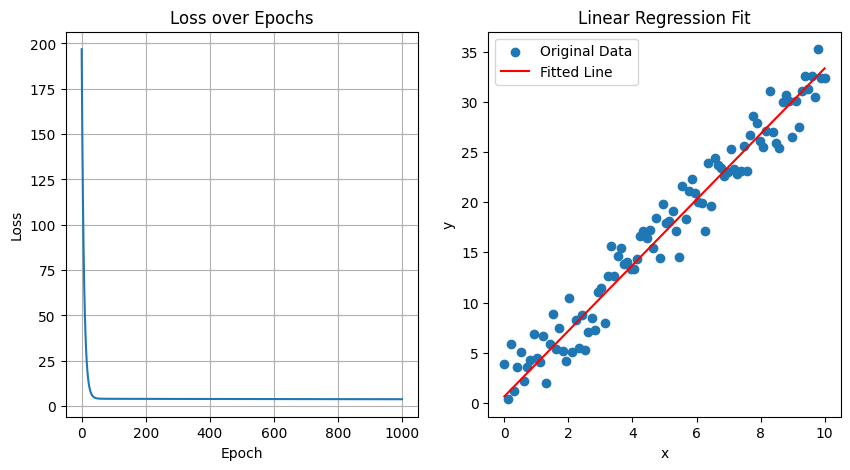

Model Parameters: 
linear.weight: tensor([[3.2685]])
linear.bias: tensor([0.6520])


In [5]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1,1) # 입력 데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.linear = nn.Linear(1,1) # 입력 1개, 출력 1개

    def forward(self, x):
        return self.linear(x)
    
model = LinearRegressionModel()

# 3. 손실 함수, 옵티마이저 정의
criterion = nn.MSELoss() # 편균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) # 확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 # 학습 반복 횟수
losses = []

for epoch in range(epochs):
    optimizer.zero_grad() # 기울기 초기화
    output = model(x) # 예측값 계산
    loss = criterion(output, y) # 손실 계산
    loss.backward() # 역전파
    optimizer.step() # 가중치 업데이트

    losses.append(loss.item())

# 100번에 한번씩 로그 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item(): .4f}")

# 5. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x.numpy(), y.numpy(), label="Original Data")
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

print("Model Parameters: ")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

### 훈련 데이터, 평가데이터 분리

Epoch [100/1000], Loss:  3.7366
Epoch [200/1000], Loss:  3.6991
Epoch [300/1000], Loss:  3.6670
Epoch [400/1000], Loss:  3.6382
Epoch [500/1000], Loss:  3.6124
Epoch [600/1000], Loss:  3.5894
Epoch [700/1000], Loss:  3.5687
Epoch [800/1000], Loss:  3.5502
Epoch [900/1000], Loss:  3.5337
Epoch [1000/1000], Loss:  3.5189
최종 Test Loss:  2.6989


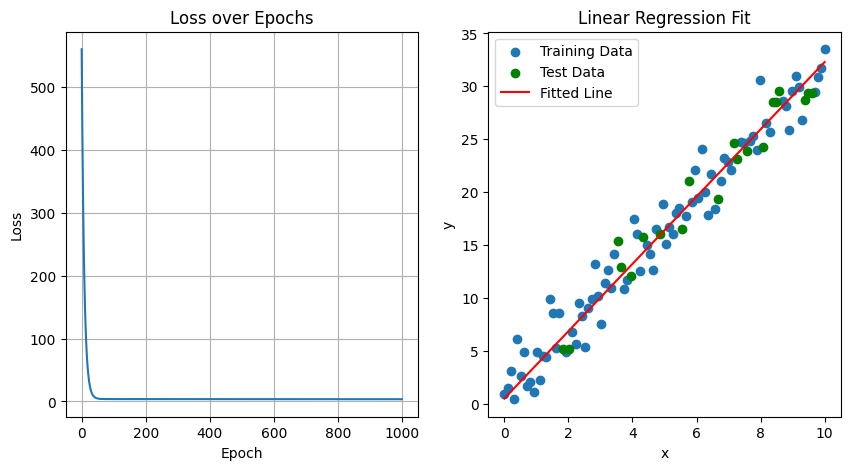

In [8]:
# 1. 데이터 생성
x = torch.linspace(0,10,100).view(-1,1) # 입력 데이터
y = 3 * x + 2 + torch.randn(100, 1) * 2

# Train / Test set 분리 (8:2로 분리)
num_train = int(len(x) * 0.8)
indices = torch.randperm(len(x))
train_idx, test_idx = indices[:num_train], indices[num_train:]

x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

# 2. 모델 정의
class LinearRegressionModel(nn.Module):
    def __init__(self,):
        super().__init__()
        self.linear = nn.Linear(1,1) # 입력 1개, 출력 1개

    def forward(self, x):
        return self.linear(x)
    
model = LinearRegressionModel()

# 3. 손실 함수, 옵티마이저 정의
criterion = nn.MSELoss() # 편균 제곱 오차
optimizer = optim.SGD(model.parameters(), lr=0.001) # 확률적 경사 하강법

# 4. 가중치 업데이트
epochs = 1000 # 학습 반복 횟수
losses = []

for epoch in range(epochs):
    optimizer.zero_grad() # 기울기 초기화
    outputs = model(x_train) # 예측값 계산
    loss = criterion(outputs, y_train) # 손실 계산
    loss.backward() # 역전파
    optimizer.step() # 가중치 업데이트

    losses.append(loss.item())

# 100번에 한번씩 로그 출력
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {loss.item(): .4f}")

# 5. 테스트 데이터 평가
with torch.no_grad():
    test_output = model(x_test)
    test_loss = criterion(test_output, y_test)
print(f"최종 Test Loss: {test_loss.item(): .4f}")

# 6. 결과 시각화
plt.figure(figsize=(10,5))

# 손실 감소 그래프
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

# 데이터와 예측 결과
plt.subplot(1, 2, 2)
plt.scatter(x_train.numpy(), y_train.numpy(), label="Training Data")
plt.scatter(x_test.numpy(), y_test.numpy(), label="Test Data", color='g')
plt.plot(x.numpy(), model(x).detach().numpy(), color="r", label="Fitted Line")
plt.title("Linear Regression Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.show()

# print("Model Parameters: ")
# for name, param in model.named_parameters():
#     print(f"{name}: {param.data}")